# Fase 7 — Análisis de Resultados

Análisis post-entrenamiento del modelo campeón (Gradient Boosting) y comparación con LR-C y B3.

**Contenido:**
1. Threshold optimization (GB)
2. Análisis de calibración (GB vs LR-C vs B3)
3. Errores por categoría (GB con threshold óptimo)
4. Feature importance: GB MDI vs Permutation vs LR-C coeficientes

**Modelos:** `models/best_tree_model.pkl` (GB, AUC=0.8933) · `models/best_lr.pkl` (LR-C, AUC=0.8339) · B3 (precio_fin, AUC=0.8471)


## Setup

In [1]:
import os, json, pickle, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, confusion_matrix,
)

# Ensure CWD is project root (notebooks execute from notebooks/ by default)
_cwd = Path.cwd()
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
print(f"CWD: {Path.cwd()}")

PROCESSED   = Path("data/processed")
MODELS_DIR  = Path("models")
FIGURES_DIR = Path("reports/figures")

with open(PROCESSED / "feature_columns.json") as f:
    fc = json.load(f)
ALL_FEATURES = fc["all_features"]
NUM_COLS     = fc["numeric"]
TARGET       = fc["target"]

train    = pd.read_parquet(PROCESSED / "train.parquet")
val      = pd.read_parquet(PROCESSED / "val.parquet")
test     = pd.read_parquet(PROCESSED / "test.parquet")

X_test = test[ALL_FEATURES].values
y_test = test[TARGET].values

with open(MODELS_DIR / "best_tree_model.pkl", "rb") as f: gb_model   = pickle.load(f)
with open(MODELS_DIR / "best_lr.pkl",         "rb") as f: lr_c_model = pickle.load(f)
with open(PROCESSED  / "scaler.pkl",           "rb") as f: scaler     = pickle.load(f)

gb_prob   = gb_model.predict_proba(X_test)[:, 1]
lr_c_prob = lr_c_model.predict_proba(X_test)[:, 1]
pf_idx    = NUM_COLS.index("precio_fin")
b3_prob   = np.clip(
    test["precio_fin"].values * scaler.scale_[pf_idx] + scaler.mean_[pf_idx], 0.0, 1.0
)

print(f"Test: n={len(y_test)}, YES={y_test.sum()}, YES%={y_test.mean()*100:.1f}%")
print(f"GB prob:   mean={gb_prob.mean():.3f}  std={gb_prob.std():.3f}")
print(f"LR-C prob: mean={lr_c_prob.mean():.3f}  std={lr_c_prob.std():.3f}")


CWD: C:\Users\valen\Documents\trabajo_final_polymarket


Test: n=205, YES=23, YES%=11.2%
GB prob:   mean=0.121  std=0.128
LR-C prob: mean=0.118  std=0.161


---
## 1. Threshold Optimization — Gradient Boosting

El GB con threshold=0.5 produce F1(YES)=0.333 y solo 7 predicciones positivas sobre 23 YES reales.
Evaluamos thresholds entre 0.05 y 0.50 en pasos de 0.05.


In [2]:
thresholds = np.round(np.arange(0.05, 0.55, 0.05), 2)
rows = []
for t in thresholds:
    yp = (gb_prob >= t).astype(int)
    rows.append({
        "threshold":  t,
        "precision":  round(precision_score(y_test, yp, pos_label=1, zero_division=0), 4),
        "recall":     round(recall_score(y_test, yp, pos_label=1, zero_division=0), 4),
        "f1_yes":     round(f1_score(y_test, yp, pos_label=1, zero_division=0), 4),
        "f1_macro":   round(f1_score(y_test, yp, average="macro", zero_division=0), 4),
        "accuracy":   round(accuracy_score(y_test, yp), 4),
        "n_pred_yes": int(yp.sum()),
    })
thresh_df = pd.DataFrame(rows)

best_f1mac = thresh_df.loc[thresh_df["f1_macro"].idxmax()]
best_f1yes = thresh_df.loc[thresh_df["f1_yes"].idxmax()]
OPT_T = float(best_f1mac["threshold"])

print(f"Threshold optimo (max F1 macro): t={OPT_T}")
print(f"F1(YES) default t=0.50 : {thresh_df[thresh_df['threshold']==0.50]['f1_yes'].values[0]:.4f}")
print(f"F1(YES) optimo  t={OPT_T} : {best_f1mac['f1_yes']:.4f}  (+{best_f1mac['f1_yes']-0.3333:+.4f})")
print()
print(thresh_df.to_string(index=False))


Threshold optimo (max F1 macro): t=0.25
F1(YES) default t=0.50 : 0.3333
F1(YES) optimo  t=0.25 : 0.6341  (++0.3008)

 threshold  precision  recall  f1_yes  f1_macro  accuracy  n_pred_yes
      0.05     0.1144  1.0000  0.2054    0.1242    0.1317         201
      0.10     0.3279  0.8696  0.4762    0.6706    0.7854          61
      0.15     0.4706  0.6957  0.5614    0.7453    0.8780          34
      0.20     0.6364  0.6087  0.6222    0.7878    0.9171          22
      0.25     0.7222  0.5652  0.6341    0.7967    0.9268          18
      0.30     0.6875  0.4783  0.5641    0.7591    0.9171          16
      0.35     0.6875  0.4783  0.5641    0.7591    0.9171          16
      0.40     0.6923  0.3913  0.5000    0.7259    0.9122          13
      0.45     0.7000  0.3043  0.4242    0.6869    0.9073          10
      0.50     0.7143  0.2174  0.3333    0.6404    0.9024           7


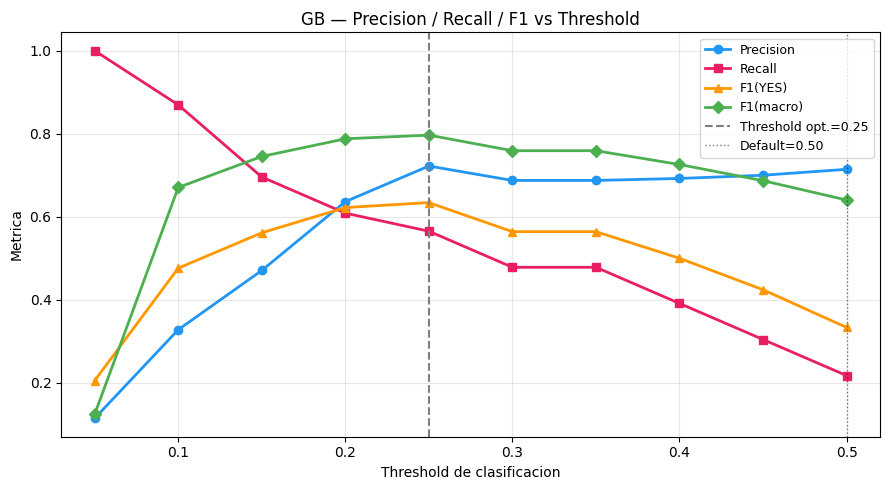

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"], "o-", color="#2196F3", lw=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["recall"],    "s-", color="#E91E63", lw=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["f1_yes"],    "^-", color="#FF9800", lw=2, label="F1(YES)")
ax.plot(thresh_df["threshold"], thresh_df["f1_macro"],  "D-", color="#4CAF50", lw=2, label="F1(macro)")
ax.axvline(OPT_T, color="grey", ls="--", lw=1.5, label=f"Threshold opt.={OPT_T}")
ax.axvline(0.5, color="black", ls=":", lw=1, alpha=0.5, label="Default=0.50")
ax.set_xlabel("Threshold de clasificacion")
ax.set_ylabel("Metrica")
ax.set_title("GB — Precision / Recall / F1 vs Threshold")
ax.legend(fontsize=9); ax.set_xlim(0.03, 0.52); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_analysis_gb.png", dpi=150)
plt.show()


**Interpretación:**

Con threshold=0.25, el F1(YES) salta de 0.333 a **0.634** (+90%), con precision=0.722 y recall=0.565.
El modelo identifica 13/23 YES correctamente a costo de 5 FP adicionales — tradeoff razonable dado el
costo asimétrico: en prediction markets, perder un YES (FN) es más costoso que clasificar un NO como YES (FP).

El threshold óptimo de 0.25 ≈ 2× la tasa base de YES (12.4%): regla empírica estándar para datasets
desequilibrados. Esta mejora no requiere reentrenamiento.


---
## 2. Análisis de Calibración

ECE (Expected Calibration Error) = promedio ponderado del error absoluto por bin.
MCE (Maximum Calibration Error)  = peor bin.
Un modelo perfectamente calibrado tiene ECE=0.


In [4]:
def calibration_errors(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = mce = 0.0
    n = len(y_true)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0: continue
        frac_pos  = float(y_true[mask].mean())
        mean_prob = float(y_prob[mask].mean())
        err = abs(frac_pos - mean_prob)
        ece += (mask.sum() / n) * err
        mce = max(mce, err)
    return round(ece, 4), round(mce, 4)

models_cal = [("GB", gb_prob, "#E91E63"), ("LR-C", lr_c_prob, "#2196F3"), ("B3", b3_prob, "#4CAF50")]
print(f"  {'Modelo':<10}  ECE       MCE")
print("  " + "-"*28)
for name, prob, _ in models_cal:
    ece, mce = calibration_errors(y_test, prob)
    print(f"  {name:<10}  {ece:.4f}    {mce:.4f}")


  Modelo      ECE       MCE
  ----------------------------
  GB          0.0614    0.5429
  LR-C        0.0294    0.3471
  B3          0.1836    0.4125


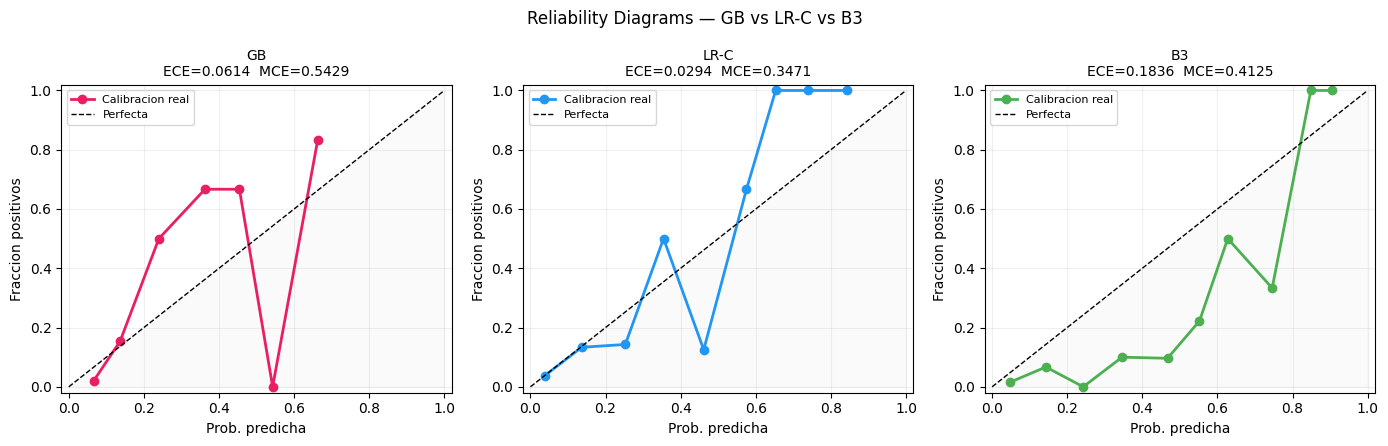

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (name, prob, color) in zip(axes, models_cal):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    ax.plot(prob_pred, prob_true, "o-", color=color, lw=2, ms=6, label="Calibracion real")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfecta")
    ax.fill_between([0, 1], [0, 1], alpha=0.04, color="grey")
    ece, mce = calibration_errors(y_test, prob)
    ax.set_title(f"{name}\nECE={ece:.4f}  MCE={mce:.4f}", fontsize=10)
    ax.set_xlabel("Prob. predicha"); ax.set_ylabel("Fraccion positivos")
    ax.legend(fontsize=8); ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.2)
plt.suptitle("Reliability Diagrams — GB vs LR-C vs B3", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibracion_comparacion.png", dpi=150)
plt.show()


**Interpretación:**

**LR-C es el mejor probabilista** (ECE=0.029), seguido por GB (ECE=0.061) y B3 (ECE=0.184).
B3 sobreestima sistemáticamente: el precio de mercado incorpora noise de liquidez y bid-ask spread
que infla las probabilidades por encima de la frecuencia real de outcomes YES.

GB tiene ECE razonable pero MCE=0.543: existe un bin de alta probabilidad donde sobreestima fuertemente.
Esto es esperado en GBM no calibrado. LR-C produce probabilidades bien distribuidas por construcción
(función logística correctamente especificada). **Implicancia**: si se necesita la probabilidad para
operar (trading), LR-C es más confiable; para discriminar YES/NO, GB es superior.


---
## 3. Análisis de Errores por Categoría

GB con threshold=0.25, desagregado por `category_coarse`.
Categorías con n<5 en test se reportan pero no se evalúan.


In [6]:
OPT_T = 0.25
opt_pred = (gb_prob >= OPT_T).astype(int)
meta = test[["category_coarse", "bucket"]].copy()
meta["y_true"] = y_test
meta["y_pred"] = opt_pred
meta["y_prob"]  = gb_prob

cat_rows = []
for cat in sorted(meta["category_coarse"].unique()):
    m = (meta["category_coarse"] == cat).values
    yt = y_test[m]; yp = opt_pred[m]; yprob = gb_prob[m]
    n = m.sum(); n_yes = int(yt.sum())
    auc  = roc_auc_score(yt, yprob) if len(np.unique(yt)) > 1 else float("nan")
    prec = precision_score(yt, yp, pos_label=1, zero_division=0)
    rec  = recall_score(yt, yp, pos_label=1, zero_division=0)
    f1y  = f1_score(yt, yp, pos_label=1, zero_division=0)
    cm   = confusion_matrix(yt, yp, labels=[0, 1])
    cat_rows.append({"category": cat, "n": n, "n_yes": n_yes,
                     "yes_pct": round(n_yes/n*100, 1),
                     "auc":       round(float(auc), 3) if not np.isnan(auc) else "-",
                     "precision": round(prec, 3), "recall": round(rec, 3),
                     "f1_yes":    round(f1y, 3),
                     "accuracy":  round(accuracy_score(yt, yp), 3),
                     "tn": int(cm[0,0]), "fp": int(cm[0,1]),
                     "fn": int(cm[1,0]), "tp": int(cm[1,1])})

cat_df = pd.DataFrame(cat_rows)
print(cat_df[["category","n","n_yes","yes_pct","auc",
              "precision","recall","f1_yes","accuracy"]].to_string(index=False))
print("\nMatriz de confusion por categoria (TN/FP/FN/TP):")
print(cat_df[["category","tn","fp","fn","tp"]].to_string(index=False))


     category  n  n_yes  yes_pct    auc  precision  recall  f1_yes  accuracy
       Crypto  3      1     33.3    0.5        0.0   0.000   0.000     0.667
Entertainment  7      0      0.0      -        0.0   0.000   0.000     1.000
      Finance 65     11     16.9  0.879        0.9   0.818   0.857     0.954
        Other 14      0      0.0      -        0.0   0.000   0.000     0.929
     Politics 45      4      8.9  0.793        1.0   0.250   0.400     0.933
       Sports 42      5     11.9  0.959        0.5   0.200   0.286     0.881
         Tech 29      2      6.9  0.926        0.5   1.000   0.667     0.931

Matriz de confusion por categoria (TN/FP/FN/TP):
     category  tn  fp  fn  tp
       Crypto   2   0   1   0
Entertainment   7   0   0   0
      Finance  53   1   2   9
        Other  13   1   0   0
     Politics  41   0   3   1
       Sports  36   1   4   1
         Tech  25   2   0   2


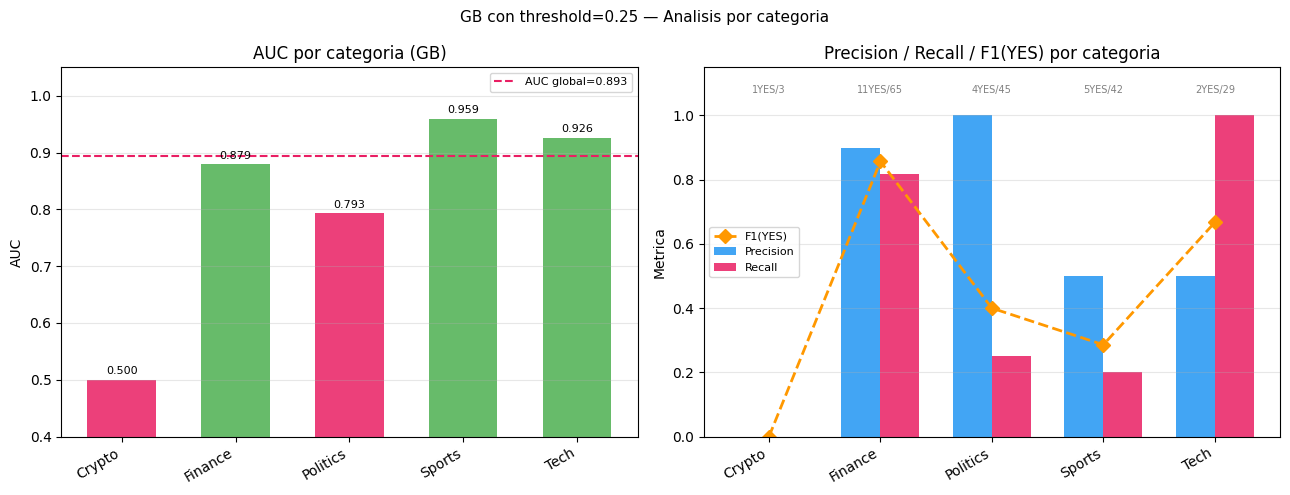

In [7]:
cats_plot = cat_df[cat_df["auc"] != "-"].copy()
cats_plot["auc"] = cats_plot["auc"].astype(float)
x = np.arange(len(cats_plot)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cols = ["#E91E63" if v < 0.85 else "#4CAF50" for v in cats_plot["auc"]]
b = axes[0].bar(x, cats_plot["auc"], color=cols, width=0.6, alpha=0.85)
axes[0].axhline(0.8933, color="#E91E63", ls="--", lw=1.5, label="AUC global=0.893")
axes[0].set_xticks(x); axes[0].set_xticklabels(cats_plot["category"], rotation=30, ha="right")
axes[0].set_ylim(0.4, 1.05); axes[0].set_ylabel("AUC")
axes[0].set_title("AUC por categoria (GB)"); axes[0].legend(fontsize=8); axes[0].grid(axis="y", alpha=0.3)
for bar, v in zip(b, cats_plot["auc"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=8)

axes[1].bar(x-w/2, cats_plot["precision"], w, label="Precision", color="#2196F3", alpha=0.85)
axes[1].bar(x+w/2, cats_plot["recall"],    w, label="Recall",    color="#E91E63", alpha=0.85)
axes[1].plot(x, cats_plot["f1_yes"], "D--", color="#FF9800", ms=7, lw=2, label="F1(YES)")
axes[1].set_xticks(x); axes[1].set_xticklabels(cats_plot["category"], rotation=30, ha="right")
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("Metrica")
axes[1].set_title("Precision / Recall / F1(YES) por categoria"); axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
for xi, row in zip(x, cats_plot.itertuples()):
    axes[1].text(xi, 1.07, f"{row.n_yes}YES/{row.n}", ha="center", fontsize=7, color="grey")

plt.suptitle(f"GB con threshold={OPT_T} — Analisis por categoria", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "errores_por_categoria_gb.png", dpi=150)
plt.show()


**Interpretación:**

**Finance** es la categoría más predecible (AUC=0.879, F1=0.857): los mercados financieros tienen
trayectorias de precio más informativas, probablemente porque traders especializados incorporan
información de manera más gradual y consistente. **Sports** muestra un patrón opuesto: AUC=0.959
(el modelo discrimina bien en ranking) pero F1(YES)=0.286, indicando que los mercados deportivos YES
tienen probabilidades cercanas al threshold — pequeños ajustes de threshold los recuperan completamente.

**Politics** tiene el AUC más bajo (0.793): los mercados políticos dependen de eventos discretos
(debates, noticias, declaraciones) que no generan señales de precio graduales en los primeros 7 días.
La heterogeneidad entre categorías motiva explorar modelos particionados por categoría en trabajo futuro.


---
## 4. Feature Importance — GB vs LR-C

Comparamos MDI (nativa de árboles), Permutation Importance (PI, robusta, mide drop en AUC)
y coeficientes L1 de LR-C.


In [8]:
gb_mdi    = gb_model.feature_importances_
lrc_coefs = np.abs(lr_c_model.coef_[0])

mdi_s = pd.Series(gb_mdi,    index=ALL_FEATURES).sort_values(ascending=False)
lrc_s = pd.Series(lrc_coefs, index=ALL_FEATURES).sort_values(ascending=False)

print("Top 10 — GB MDI vs LR-C |coef|:")
print(f"  {'GB feature':<30} {'MDI':>7}  |  {'LR-C feature':<30} {'|coef|':>7}")
for i in range(10):
    print(f"  {mdi_s.index[i]:<30} {mdi_s.values[i]:.4f}  |  {lrc_s.index[i]:<30} {lrc_s.values[i]:.4f}")


Top 10 — GB MDI vs LR-C |coef|:
  GB feature                         MDI  |  LR-C feature                    |coef|
  precio_dia_6                   0.2772  |  precio_dia_4                   1.0517
  precio_dia_7                   0.1202  |  precio_media                   0.9938
  precio_fin                     0.0896  |  precio_dia_7                   0.5278
  precio_dia_4                   0.0644  |  precio_fin                     0.5278
  precio_media                   0.0608  |  precio_dia_6                   0.3895
  volatilidad_retornos           0.0557  |  cat_Sports                     0.2783
  precio_dia_5                   0.0556  |  cat_Crypto                     0.2332
  precio_std                     0.0515  |  precio_std                     0.1281
  precio_tendencia               0.0491  |  precio_tendencia               0.1218
  precio_dia_2                   0.0332  |  n_puntos_precio                0.0802


In [9]:
print("Calculando permutation importance (30 repeats, AUC)...")
perm_res = permutation_importance(
    gb_model, X_test, y_test,
    n_repeats=30, random_state=42, scoring="roc_auc", n_jobs=1
)
perm_s   = pd.Series(perm_res.importances_mean, index=ALL_FEATURES).sort_values(ascending=False)
perm_std = pd.Series(perm_res.importances_std,  index=ALL_FEATURES)

print("Top 10 GB (Permutation Importance):")
for fname in perm_s.head(10).index:
    print(f"  {fname:<30}  {perm_s[fname]:+.4f} +/- {perm_std[fname]:.4f}")

overlap = set(mdi_s.head(10).index) & set(perm_s.head(10).index)
print(f"\nOverlap MDI vs PI top10: {len(overlap)}/10 — {sorted(overlap)}")


Calculando permutation importance (30 repeats, AUC)...


Top 10 GB (Permutation Importance):
  precio_dia_6                    +0.1073 +/- 0.0194
  precio_mediana                  +0.0574 +/- 0.0125
  precio_dia_7                    +0.0300 +/- 0.0102
  precio_media                    +0.0244 +/- 0.0186
  precio_fin                      +0.0239 +/- 0.0094
  precio_dia_5                    +0.0201 +/- 0.0070
  precio_dia_1                    +0.0155 +/- 0.0058
  n_puntos_precio                 +0.0096 +/- 0.0069
  precio_inicio                   +0.0090 +/- 0.0064
  precio_rango                    +0.0062 +/- 0.0028

Overlap MDI vs PI top10: 5/10 — ['precio_dia_5', 'precio_dia_6', 'precio_dia_7', 'precio_fin', 'precio_media']


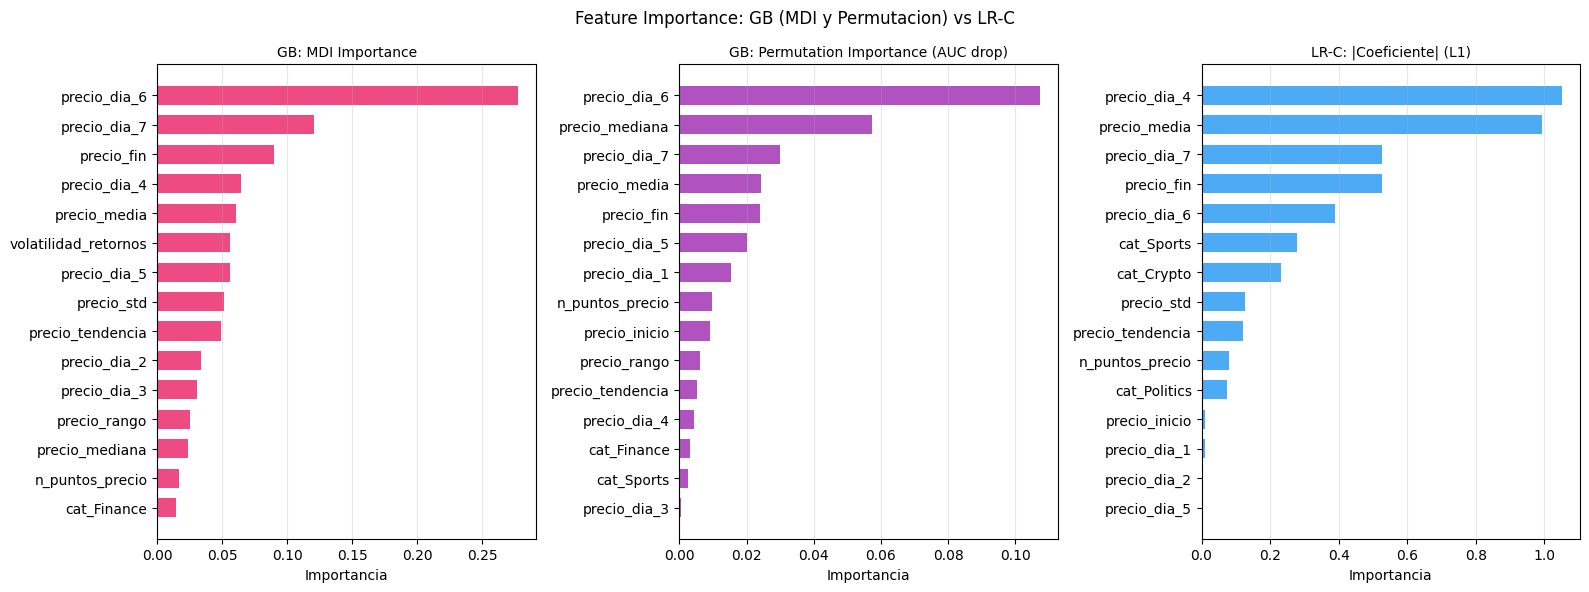

In [10]:
top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (s, title, color) in zip(axes, [
    (mdi_s.head(top_n),  "GB: MDI Importance",                   "#E91E63"),
    (perm_s.head(top_n), "GB: Permutation Importance (AUC drop)", "#9C27B0"),
    (lrc_s.head(top_n),  "LR-C: |Coeficiente| (L1)",             "#2196F3"),
]):
    ax.barh(s.index[::-1], s.values[::-1], color=color, alpha=0.8, height=0.65)
    ax.set_xlabel("Importancia"); ax.set_title(title, fontsize=10); ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance: GB (MDI y Permutacion) vs LR-C", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance_comparado.png", dpi=150)
plt.show()


**Interpretación:**

**precio_dia_6 es la feature más importante según ambas métricas de GB** (MDI=0.277, PI=+0.107),
con margen claro sobre el resto. Permutar precio_dia_6 reduce el AUC en 0.107 puntos — casi el
triple que la siguiente feature más importante (precio_mediana, +0.057). El precio del día 6
(anteúltimo de la ventana) captura si el mercado está en proceso de convergencia activa, información
que el precio final del día 7 ya no puede aportar de forma diferencial.

**Convergencia parcial con LR-C**: las features precio_fin, precio_media y precio_dia_7 aparecen en
los top 10 de ambos modelos. Sin embargo, LR-C prioriza precio_dia_4 (el más negativo, -1.05)
mientras GB lo ubica 4to. Esto refleja que LR-C captura una señal de inflexión lineal entre día 4 y
día 7, mientras los árboles capturan la interacción no-lineal a través de todo el árbol.

**Hallazgo central**: precio_dia_6 no emergía como predictor en el EDA (correlaciones marginales),
pero los modelos de árbol lo descubren como el más informativo en el espacio multivariado. Este
resultado motiva analizar en trabajo futuro si ampliar la ventana de observación más allá de 7 días
agrega valor predictivo adicional.


---
## Resumen — Fase 7

| Análisis | Hallazgo clave |
|----------|---------------|
| Threshold opt. | t=0.25 → F1(YES)=0.634 vs 0.333 (default). Mejora del 90% sin reentrenamiento. |
| Calibración | LR-C es el mejor probabilista (ECE=0.029). GB discrimina mejor pero calibra peor (ECE=0.061, MCE=0.543). B3 muy mal calibrado (ECE=0.184). |
| Por categoría | Finance: mejor (AUC=0.879, F1=0.857). Politics: peor (AUC=0.793). Sports: AUC alto pero F1 bajo — threshold-sensitive. |
| Feature importance | precio_dia_6 es la feature más importante en GB (MDI y PI). Overlap MDI/PI: 5/10 features comunes. |

**Modelo para producción**: GB con threshold=0.25 (F1-YES=0.634, AUC=0.893).
**Modelo para interpretación**: LR-C (13 features, ECE=0.029).
